In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
data = pd.read_pickle("C:\PROJECT-DEMETER\Demeter_Retrain\Data\Down_Orbits-max-val-location.pkl")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_5784\4156762528.py:1: SyntaxWarning: invalid escape sequence '\P'
  data = pd.read_pickle("C:\PROJECT-DEMETER\Demeter_Retrain\Data\Down_Orbits-max-val-location.pkl")


In [16]:
fbs = ['fb_1','fb_2','fb_3','fb_4','fb_5','fb_6','fb_7','fb_8','fb_9','fb_10','fb_11']


In [ ]:
specific_key ='G89'
fb = fbs[5]

In [15]:
all_band_values = {}
total_samples = sum(len(grid_data) for grid_data in data[specific_key])

# if total_samples <= 100:
#     continue  # Exit if total samples are insufficient

for grid_data in data[specific_key]:
    for band_key, band_data in grid_data.items():
        if band_key == fb: 
            if band_key in all_band_values:
                all_band_values[band_key].append(band_data)
            else:
                all_band_values[band_key] = [band_data]

for band_key, band_values in all_band_values.items():
    # Extract datetime, Q3, and Max values and convert to DataFrame
    datetime_values = [pd.to_datetime(entry['datetime']) for entry in band_values]
    q3_values = [entry['Q3'] for entry in band_values]
    lat = [entry['lat'] for entry in band_values]
    lon = [entry['lon'] for entry in band_values]
    df= pd.DataFrame({
        'datetime': datetime_values,
        f'Q3_{band_key}': q3_values,
        'lat': lat,
        'lon':lon,
        # f'max_{band_key}':max_values

    })

    df.set_index('datetime', inplace=True)

In [5]:
df_c= pd.read_pickle("C:\PROJECT-DEMETER\Demeter_Retrain\Data\Down_Orbits-max-val-location.pkl")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_5784\2318863849.py:1: SyntaxWarning: invalid escape sequence '\P'
  df_c= pd.read_pickle("C:\PROJECT-DEMETER\Demeter_Retrain\Data\Down_Orbits-max-val-location.pkl")


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates



def plot_single_fb_q3(df):
    """
    Plot Q3 time series for a single frequency band (fb) for one grid key.

    Parameters
    ----------
    data : dict
        data[specific_key] -> list of grid_data dicts with fb_* keys.
    specific_key : str
        Grid key (e.g. 'G89').
    fb : str
        Frequency band key, e.g. 'fb_1', 'fb_2', ..., 'fb_11'.
    """

    # Journal-style formatting
    mpl.rcParams.update({

        "font.family": "serif",
        "font.serif": ["Times New Roman"],

    })



    # Plot
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.scatter(df.index, df["Res_Q3_fb_6"], s=35)
    ax.set_xlabel("Time (UTC)", fontsize=23)
    ax.set_ylabel(" Q3 Residual ", fontsize=23)
    ax.set_title(f"Input Feature - FB6", fontsize=23)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=23)
    ax.set_ylim([-2,2])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    fig.tight_layout()
    # plt.savefig(f"C:\PROJECT-DEMETER\Paper1\Plots\IEEE\\fig_3.png",dpi=600)
    # plt.savefig(f"C:\PROJECT-DEMETER\Paper1\Plots\IEEE\\fig_3.eps",dpi=600)
    # plt.show()
    plt.savefig(r"C:\PROJECT-DEMETER\Paper1\Plots\fig_input.png", dpi=600, bbox_inches='tight')
    plt.savefig(r"C:\PROJECT-DEMETER\Paper1\Plots\fig_input.eps", dpi=600, bbox_inches='tight')
    plt.show()

    return fig, ax


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


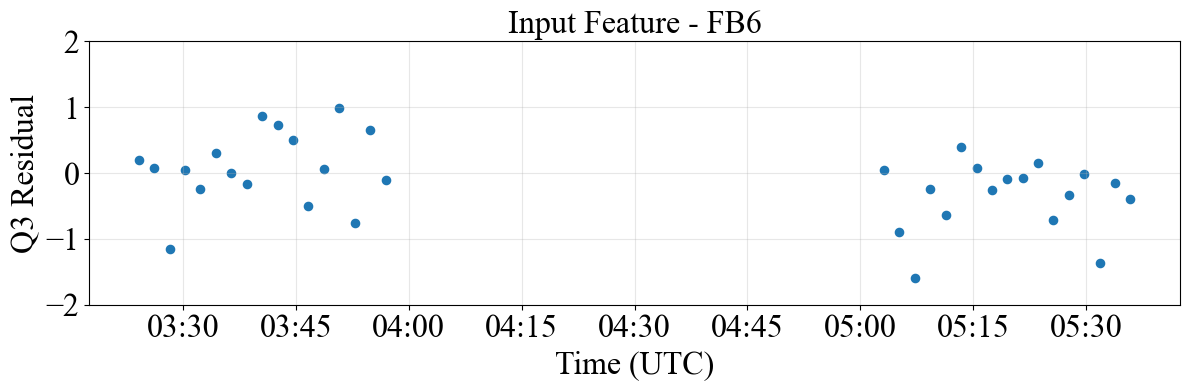

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'Input Feature - FB6'}, xlabel='Time (UTC)', ylabel=' Q3 Residual '>)

In [9]:
plot_single_fb_q3(data[33:67])

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from functools import reduce
import math


def plot_q3_bands_subplots(data, specific_key='G89', fbs=None):
    """
    Plot Q3 time series for all frequency bands of a given grid key
    as subplots with journal-style formatting.

    Parameters
    ----------
    data : dict
        Nested dict structure as in your code:
        data[specific_key] -> list of grid_data dicts with fb_* keys.
    specific_key : str
        Grid key (e.g. 'G89').
    fbs : list of str, optional
        List of band keys (e.g. ['fb_1', ..., 'fb_11']).
        If None, defaults to fb_1..fb_11.
    """

    # ---------------- Journal-style formatting ----------------
    plt.rcParams.update({
        "font.family": "Cambria",   # will fall back if not available
        "font.size": 12,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })

    if fbs is None:
        fbs = [f'fb_{i}' for i in range(1, 12)]  # fb_1 ... fb_11

    # Collect band data
    all_band_values = {fb: [] for fb in fbs}

    for grid_data in data[specific_key]:
        for band_key, band_data in grid_data.items():
            if band_key in fbs:
                all_band_values[band_key].append(band_data)

    # Build one DataFrame per band and merge on datetime
    dfs = []
    for band_key, band_values in all_band_values.items():
        if not band_values:
            continue

        datetime_values = [pd.to_datetime(entry['datetime']) for entry in band_values]
        q3_values       = [entry['Q3'] for entry in band_values]

        df_band = pd.DataFrame({
            'datetime': datetime_values,
            f'Q3_{band_key}': q3_values,
        })

        # Optional: aggregate if duplicate timestamps
        # df_band = df_band.groupby('datetime', as_index=False).mean()

        dfs.append(df_band)

    if not dfs:
        raise ValueError(f"No data found for key '{specific_key}'.")

    merged = reduce(
        lambda left, right: pd.merge(left, right, on='datetime', how='outer'),
        dfs
    )
    merged = merged.set_index('datetime').sort_index()

    # ---------------- Subplot layout ----------------
    n_bands = len(fbs)
    ncols = 3
    nrows = math.ceil(n_bands / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(12, 3 * nrows),
        sharex=True
    )

    axes = axes.flatten()

    for i, fb in enumerate(fbs):
        col = f'Q3_{fb}'
        ax = axes[i]
        if col in merged.columns:
            ax.scatter(merged.index, merged[col])
            ax.set_title(fb, loc="left")  # simple band label
            ax.set_ylabel("Q3")
            ax.grid(True, alpha=0.3)
        else:
            ax.set_visible(False)

    # X-label only on bottom row
    for i, ax in enumerate(axes):
        if i >= (nrows - 1) * ncols:
            if ax.get_visible():
                ax.set_xlabel("Datetime")

    # Hide any extra axes (e.g., 12th one if you have only 11 bands)
    for j in range(n_bands, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Q3 time series for all frequency bands (grid {specific_key})",
                 fontsize=14, fontweight="bold", y=0.99)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    return fig, axes


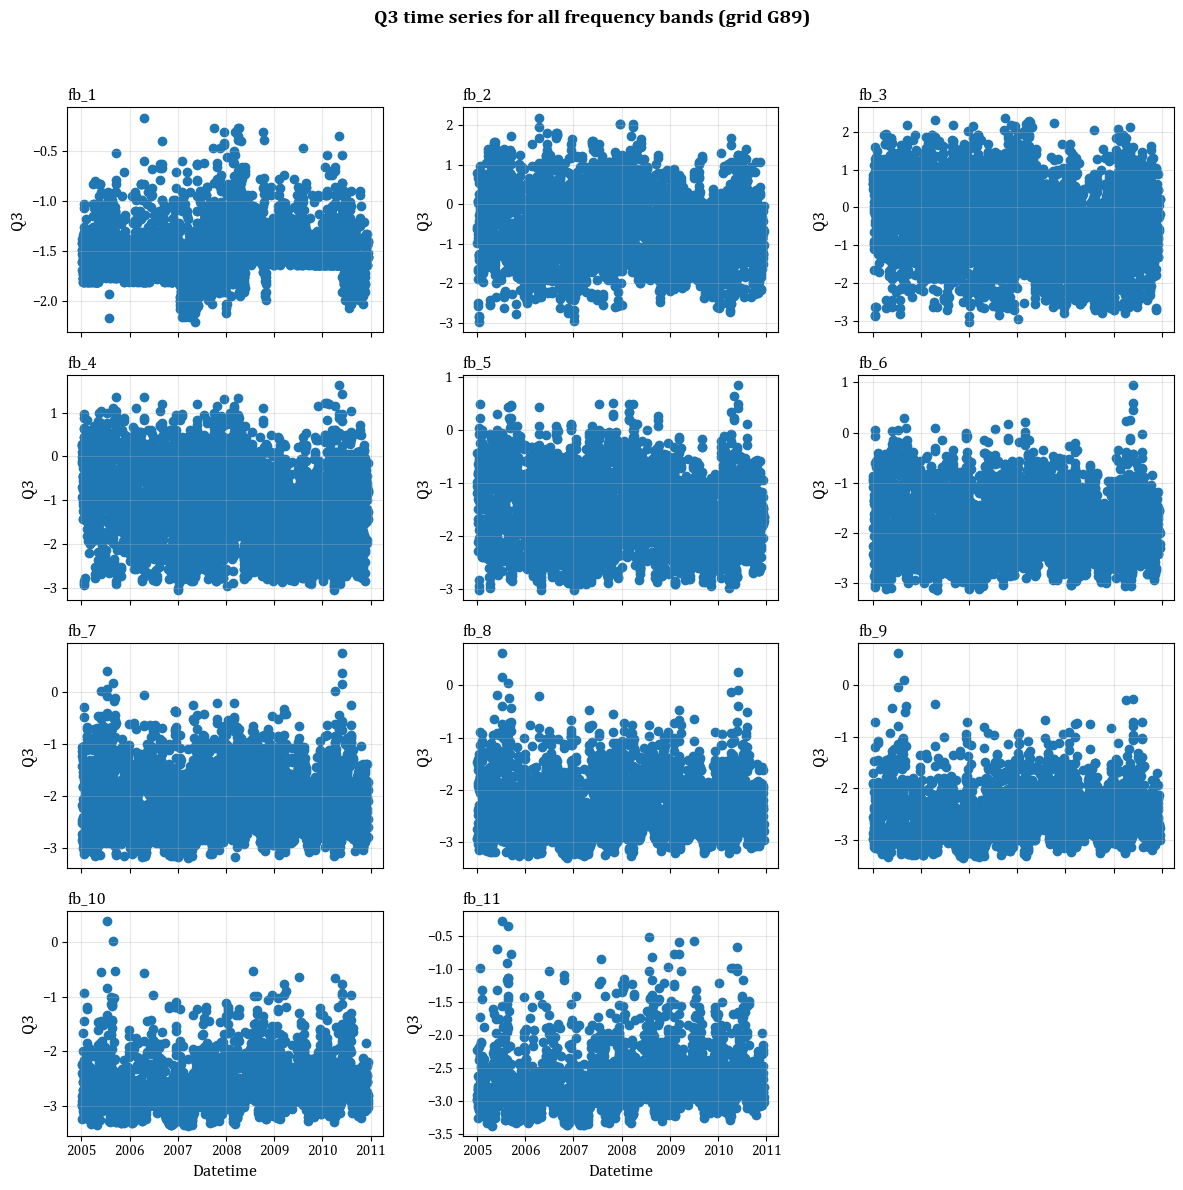

In [18]:
fig, axes = plot_q3_bands_subplots(data, specific_key='G89')


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_single_fb_q3(data, specific_key='G89', fb='fb_5'):
    """
    Plot Q3 time series for a single frequency band (fb) for one grid key.

    Parameters
    ----------
    data : dict
        data[specific_key] -> list of grid_data dicts with fb_* keys.
    specific_key : str
        Grid key (e.g. 'G89').
    fb : str
        Frequency band key, e.g. 'fb_1', 'fb_2', ..., 'fb_11'.
    """

    # Journal-style formatting
    mpl.rcParams.update({

        "font.family": "serif",
        "font.serif": ["Times New Roman"],

    })

# --- Setup ---
    # Collect entries for the chosen band
    band_values = []
    for grid_data in data[specific_key]:
        if fb in grid_data:
            band_values.append(grid_data[fb])

    if not band_values:
        raise ValueError(f"No data found for {fb} in key '{specific_key}'.")

    # Build dataframe
    datetime_values = [pd.to_datetime(entry['datetime']) for entry in band_values]
    q3_values       = [entry['Q3'] for entry in band_values]

    df = pd.DataFrame({
        'datetime': datetime_values,
        'Q3': q3_values,
    }).sort_values('datetime')

    df.set_index('datetime', inplace=True)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.scatter(df.index, df["Q3"], s=5)
    ax.set_xlabel("Year", fontsize=23)
    ax.set_ylabel(" Quartile feature Q3 ", fontsize=23)
    ax.set_title(f"Q3 time series for FB5 (grid {specific_key})", fontsize=23)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=23)
    ax.set_ylim([-3.5,4])
    

    fig.tight_layout()
    # plt.savefig(f"C:\PROJECT-DEMETER\Paper1\Plots\IEEE\\fig_3.png",dpi=600)
    # plt.savefig(f"C:\PROJECT-DEMETER\Paper1\Plots\IEEE\\fig_3.eps",dpi=600)
    # plt.show()
    # plt.savefig(r"C:\PROJECT-DEMETER\Paper1\Plots\Remote Sensing\Plots\fig_3.png", dpi=600, bbox_inches='tight')
    # plt.savefig(r"C:\PROJECT-DEMETER\Paper1\Plots\Remote Sensing\Plots\fig_3.eps", dpi=600, bbox_inches='tight')
    plt.show()

    return fig, ax


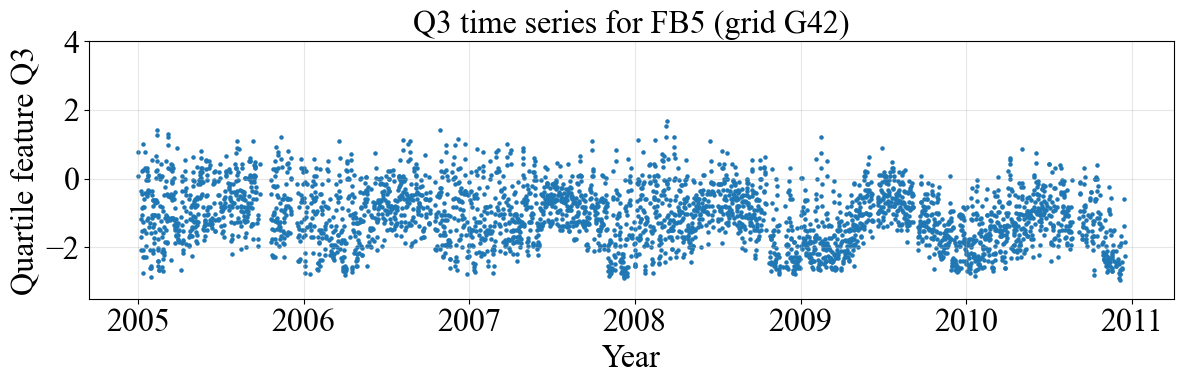

In [20]:
fig, ax = plot_single_fb_q3(data, specific_key='G42', fb='fb_5')
